In [83]:
import numpy as np
import matplotlib.pyplot as plt
import keras
import cv2
from keras.applications import MobileNetV2
from keras.models import Sequential, Model
from keras.layers import Dense, GlobalAveragePooling2D
from keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
import pickle

In [84]:
# Set random seed for reproducibility
np.random.seed(0)

In [85]:
# Unpickle the file
with open(r'/content/images.p', 'rb') as f:
    images = pickle.load(f)

with open(r'/content/labels.p', 'rb') as f:
    labels = pickle.load(f)

In [86]:
set(labels)

{np.str_('.DS'), np.str_('CHIKU'), np.str_('CHINU'), np.str_('MAMA')}

In [87]:
import numpy as np
labels_list = labels.tolist()
labels_list.remove(".DS")
labels = np.array(labels_list)

In [88]:
set(labels)

{np.str_('CHIKU'), np.str_('CHINU'), np.str_('MAMA')}

In [89]:
# Encoding Part
le = LabelEncoder()
labels = le.fit_transform(labels)

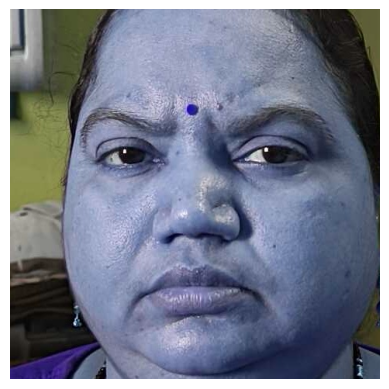

In [90]:
# Plotting part
plt.imshow(images[300])
plt.axis('off')
plt.show()

In [91]:
# Conversion of the labels to 'To categorical'
labels = to_categorical(labels, 3)

In [92]:
def preprocessing(img):
    if img is None:
        return np.zeros((100, 100, 3), dtype=np.float32)  # Return a blank image if None

    if len(img.shape) == 3:  # If the image has multiple channels (not grayscale)
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)  # Convert to grayscale
    img = cv2.equalizeHist(img)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)  # Convert back to RGB
    img = cv2.resize(img, (100, 100))  # Resize to the desired size
    img = img / 255.0
    return img


In [93]:
images = np.array(list(map(preprocessing, images)))
print("Shape of Input: ", images.shape)

Shape of Input:  (301, 100, 100, 3)


In [94]:
categories = labels.shape[1]

In [95]:
def mobilenet_cnn_model():
    base_model = MobileNetV2(input_shape=(100, 100, 3), include_top=False, weights='imagenet')

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(200, activation='relu')(x)
    predictions = Dense(categories, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [96]:
model = mobilenet_cnn_model()

<ipython-input-95-c3510a09eb00>:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(100, 100, 3), include_top=False, weights='imagenet')


In [97]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 100, 100, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 50, 50, 32)     │            864 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 50, 50, 32)     │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 50, 50, 32)     │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 50, 50, 32)     │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 50, 50, 32)     │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 50, 50, 32)     │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 50, 50, 16)     │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 50, 50, 16)     │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 50, 50, 96)     │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 50, 50, 96)     │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 50, 50, 96)     │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 51, 51, 96)     │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 25, 25, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,514,787 (9.59 MB)

 Trainable params: 2,480,675 (9.46 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [98]:
min_samples = min(len(images), len(labels))  # Find the smallest dataset size

images = images[:min_samples]  # Trim to match size
labels = labels[:min_samples]  # Trim to match size

history = model.fit(images, labels, validation_split=0.1, epochs=20, verbose=1)


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.5002 - loss: 1.2736 - val_accuracy: 0.5333 - val_loss: 1.5135
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6566 - loss: 0.7558 - val_accuracy: 0.4333 - val_loss: 2.3831
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6475 - loss: 0.7660 - val_accuracy: 0.5333 - val_loss: 1.9837
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6633 - loss: 0.6513 - val_accuracy: 0.5333 - val_loss: 1.5123
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8093 - loss: 0.5289 - val_accuracy: 0.6000 - val_loss: 1.4798
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7672 - loss: 0.6067 - val_accuracy: 0.6333 - val_loss: 1.5031
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8539 - loss: 0.3512 - val_accuracy: 0.5000 - val_loss: 2.0383
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8484 - loss: 0.3760 - val_accuracy: 0.2667 - val_loss: 2.8263
E

In [99]:
# Save the model
model.save("final_model_mobilenetv2.h5")

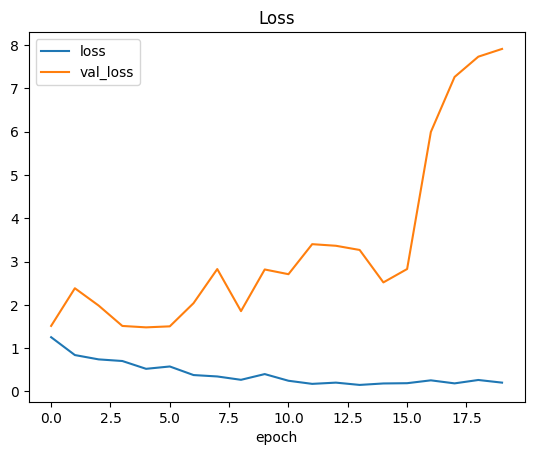

In [100]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.title('Loss')
plt.xlabel('epoch')
plt.show()